# 进行传统深度学习模型的复现，作为对照试验的效果。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import re
import sys
from pathlib import Path
notebook_path = Path(sys.argv[0]).parent if "ipykernel" in sys.argv[0] else Path.cwd()
sys.path.append(str(notebook_path))
from utils import use  
from utils import dbn_model as dbnm


# 1.CNN-Bi-LSTM模型

In [7]:
class CNN_BiLSTM_SOTA(nn.Module):
    def __init__(self, num_classes):
        super(CNN_BiLSTM_SOTA, self).__init__()
        # 特征提取阶段：模仿 WDCNN 的多层卷积思路
        self.feature_extractor = nn.Sequential(
            # Layer 1: 大卷积核捕捉低频轮廓
            nn.Conv1d(1, 16, kernel_size=64, stride=8, padding=28),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Layer 2: 中卷积核
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Layer 3: 深层提取
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 序列建模：双层 BiLSTM
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, 
                            num_layers=2, bidirectional=True, 
                            batch_first=True, dropout=0.3)
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(128 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)  # (Batch, 64, L_new)
        x = x.transpose(1, 2)          # (Batch, L_new, 64)
        x, _ = self.lstm(x)
        x = x[:, -1, :]                # 提取最后一个时间步的特征
        return self.classifier(x)

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
划分完成 -> 训练集: 22080, 测试集: 5503
开始训练 CNN-BiLSTM SOTA 模型 (设备: cuda)...
Epoch [01/250] Train Loss: 2.2484 | Train Acc: 21.41% | Test Loss: 2.2449 | Test Acc: 25.08% | F1: 0.0401
Epoch [02/250] Train Loss: 2.1332 | Train Acc: 23.26% | Test Loss: 2.2029 | Test Acc: 28.33% | F1: 0.1213
Epoch [03/250] Train Loss: 2.0595 | Train Acc: 24.66% | Test Loss: 2.1494 | Test Acc: 30.27% | F1: 0.2948
Epoch [04/250] Train Loss: 1.9965 | Train Acc: 26.83% | Test Loss: 1.9890 | Test Acc: 33.24% | F1: 0.3066
Epoch [05/250] Train Loss: 1.9368 | Train Acc: 27.43% | Test Loss: 1.9475 | Test Acc: 33.96% | F1: 0.2826
Epoch [06/250] Train Loss: 1.8950 | Train Acc: 29.29% | Test Loss: 1.9379 | Test Acc: 34.33% | F1: 0.2881
Epoch [07/250] Train Loss: 1.8466 | Train Acc: 31.48% | Test Loss: 1.8660 | Test Acc: 35.74% | F1: 0.3343
Epoch [08/250] Train Loss: 1.7982 | Train Acc: 34.46% | Test 

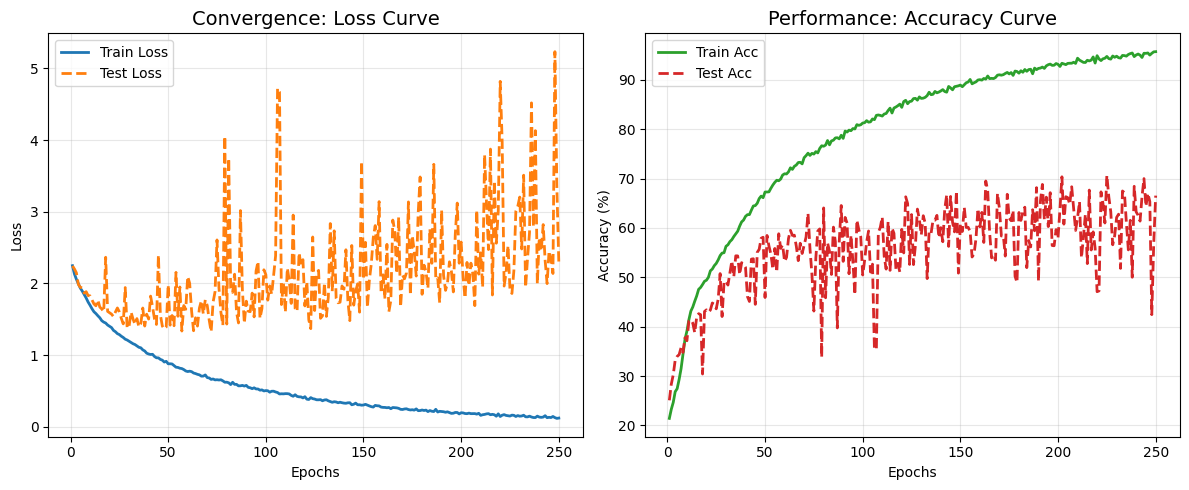


🚀 最终评估结果报表
最终测试准确率: 66.55%
最终测试 F1 值 (Macro): 0.6383


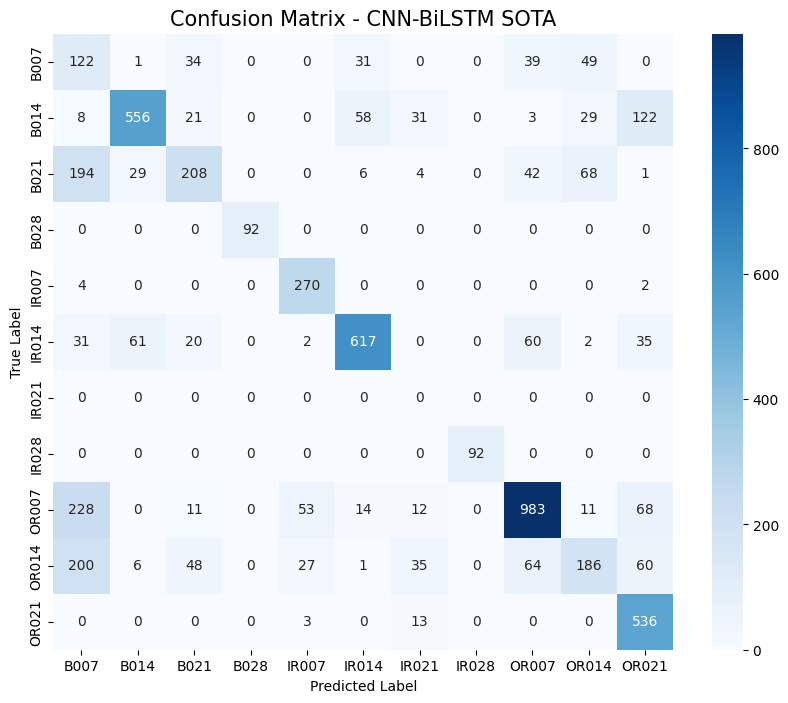


详细分类报告:
              precision    recall  f1-score   support

        B007       0.16      0.44      0.23       276
        B014       0.85      0.67      0.75       828
        B021       0.61      0.38      0.47       552
        B028       1.00      1.00      1.00        92
       IR007       0.76      0.98      0.86       276
       IR014       0.85      0.75      0.79       828
       IR021       0.00      0.00      0.00         0
       IR028       1.00      1.00      1.00        92
       OR007       0.83      0.71      0.76      1380
       OR014       0.54      0.30      0.38       627
       OR021       0.65      0.97      0.78       552

    accuracy                           0.67      5503
   macro avg       0.66      0.65      0.64      5503
weighted avg       0.73      0.67      0.68      5503



d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
if __name__ == '__main__':
    # --- 基础设置 ---
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    
    # 1. 加载数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))

    # 2. 划分数据集 (基于 ID 进行 GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    # 3. 预处理 (归一化并 Reshape 为 Conv1d 输入格式: [N, 1, 2048])
    scaler = MinMaxScaler()
    X_train_flat = X[train_idx].reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 1, 2048)
    
    X_test_flat = X[test_idx].reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 1, 2048)

    print(f"划分完成 -> 训练集: {len(X_train_flat)}, 测试集: {len(X_test_flat)}")

    # 转换为 Tensor (纯振动信号)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y[test_idx], dtype=torch.long)

    # 4. DataLoader
    batch_size = 128
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

    # 5. 初始化强化版模型
    model = CNN_BiLSTM_SOTA(num_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    # 准备记录训练过程的容器
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # 6. 训练循环
    num_epochs = 250
    print(f"开始训练 CNN-BiLSTM SOTA 模型 (设备: {device})...")
    
    for epoch in range(num_epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- 验证阶段 ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = 100. * test_correct / test_total
        epoch_test_f1 = f1_score(all_labels, all_preds, average='macro')

        # 记录到 history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}% | F1: {epoch_test_f1:.4f}")

    # -----------------------------------------------------------
    # 7. 绘图：损失与准确率曲线 (收敛证明)
    # -----------------------------------------------------------
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    # 子图 1: Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='#ff7f0e', linestyle='--', lw=2)
    plt.title('Convergence: Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图 2: Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='#d62728', linestyle='--', lw=2)
    plt.title('Performance: Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # 8. 最终评估与混淆矩阵 (严谨性证明)
    # -----------------------------------------------------------
    print("\n" + "="*30)
    print("🚀 最终评估结果报表")
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"最终测试准确率: {epoch_test_acc:.2f}%")
    print(f"最终测试 F1 值 (Macro): {final_f1:.4f}")
    
    # 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_strs, yticklabels=label_strs)
    plt.title('Confusion Matrix - CNN-BiLSTM SOTA', fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\n详细分类报告:")
    print(classification_report(all_labels, all_preds, target_names=label_strs))

# 二、WDCNN

In [3]:
import torch
import torch.nn as nn

class WDCNN(nn.Module):
    def __init__(self, num_classes):
        super(WDCNN, self).__init__()
        
        # Layer 1: 宽卷积 (k=64, s=8, p=28)
        self.layer1 = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=8, padding=28), 
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Layer 2
        self.layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Layer 3
        self.layer3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Layer 4
        self.layer4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Layer 5
        self.layer5 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # 【核心改动】：使用全局平均池化，将维度强制统一
        # 这样无论前面卷积后长度是多少，输出都是 (Batch, 128, 1)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        # 3. 分类器
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 100), # 这里的输入永远是 layer5 的输出通道数 128
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(100, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.adaptive_pool(x)
        x = self.fc(x)
        return x

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
划分完成 -> 训练集: 22080, 测试集: 5503
开始训练 CNN-BiLSTM SOTA 模型 (设备: cuda)...
Epoch [01/500] Train Loss: 2.3336 | Train Acc: 18.31% | Test Loss: 2.3140 | Test Acc: 25.91% | F1: 0.1070
Epoch [02/500] Train Loss: 2.2623 | Train Acc: 22.45% | Test Loss: 2.2643 | Test Acc: 26.75% | F1: 0.1406
Epoch [03/500] Train Loss: 2.2178 | Train Acc: 23.34% | Test Loss: 2.2353 | Test Acc: 26.75% | F1: 0.1406
Epoch [04/500] Train Loss: 2.1859 | Train Acc: 23.73% | Test Loss: 2.2185 | Test Acc: 26.75% | F1: 0.1406
Epoch [05/500] Train Loss: 2.1628 | Train Acc: 23.55% | Test Loss: 2.2076 | Test Acc: 26.75% | F1: 0.1406
Epoch [06/500] Train Loss: 2.1471 | Train Acc: 24.19% | Test Loss: 2.1980 | Test Acc: 26.75% | F1: 0.1396
Epoch [07/500] Train Loss: 2.1323 | Train Acc: 24.11% | Test Loss: 2.1908 | Test Acc: 26.75% | F1: 0.1407
Epoch [08/500] Train Loss: 2.1186 | Train Acc: 24.07% | Test 

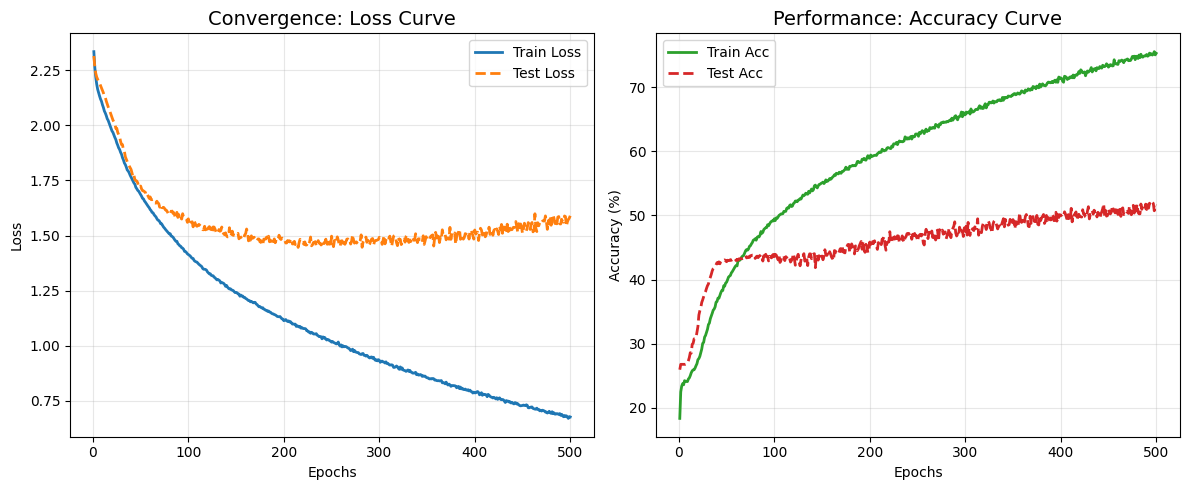


🚀 最终评估结果报表
最终测试准确率: 51.54%
最终测试 F1 值 (Macro): 0.5220


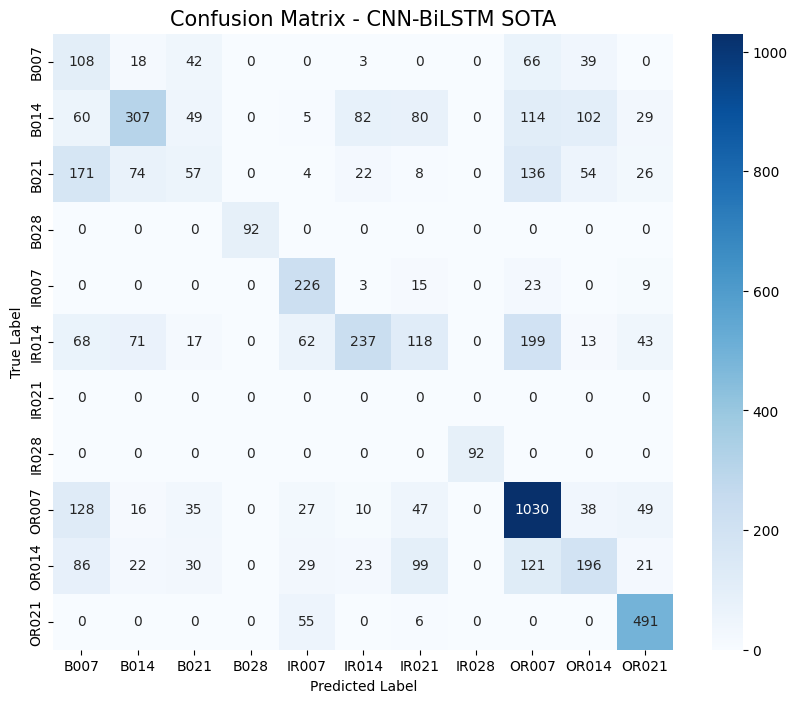


详细分类报告:
              precision    recall  f1-score   support

        B007       0.17      0.39      0.24       276
        B014       0.60      0.37      0.46       828
        B021       0.25      0.10      0.15       552
        B028       1.00      1.00      1.00        92
       IR007       0.55      0.82      0.66       276
       IR014       0.62      0.29      0.39       828
       IR021       0.00      0.00      0.00         0
       IR028       1.00      1.00      1.00        92
       OR007       0.61      0.75      0.67      1380
       OR014       0.44      0.31      0.37       627
       OR021       0.74      0.89      0.80       552

    accuracy                           0.52      5503
   macro avg       0.54      0.54      0.52      5503
weighted avg       0.56      0.52      0.51      5503



d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [7]:
if __name__ == '__main__':
    # --- 基础设置 ---
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    
    # 1. 加载数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))

    # 2. 划分数据集 (基于 ID 进行 GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    # 3. 预处理 (归一化并 Reshape 为 Conv1d 输入格式: [N, 1, 2048])
    scaler = MinMaxScaler()
    X_train_flat = X[train_idx].reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 1, 2048)
    
    X_test_flat = X[test_idx].reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 1, 2048)

    print(f"划分完成 -> 训练集: {len(X_train_flat)}, 测试集: {len(X_test_flat)}")

    # 转换为 Tensor (纯振动信号)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y[test_idx], dtype=torch.long)

    # 4. DataLoader
    batch_size = 128
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

    # 5. 初始化强化版模型
    model = WDCNN(num_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.00001)
    criterion = nn.CrossEntropyLoss()

    # 准备记录训练过程的容器
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # 6. 训练循环
    num_epochs = 500
    print(f"开始训练 CNN-BiLSTM SOTA 模型 (设备: {device})...")
    
    for epoch in range(num_epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- 验证阶段 ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = 100. * test_correct / test_total
        epoch_test_f1 = f1_score(all_labels, all_preds, average='macro')

        # 记录到 history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}% | F1: {epoch_test_f1:.4f}")

    # -----------------------------------------------------------
    # 7. 绘图：损失与准确率曲线 (收敛证明)
    # -----------------------------------------------------------
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    # 子图 1: Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='#ff7f0e', linestyle='--', lw=2)
    plt.title('Convergence: Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图 2: Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='#d62728', linestyle='--', lw=2)
    plt.title('Performance: Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # 8. 最终评估与混淆矩阵 (严谨性证明)
    # -----------------------------------------------------------
    print("\n" + "="*30)
    print("🚀 最终评估结果报表")
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"最终测试准确率: {epoch_test_acc:.2f}%")
    print(f"最终测试 F1 值 (Macro): {final_f1:.4f}")
    
    # 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_strs, yticklabels=label_strs)
    plt.title('Confusion Matrix - CNN-BiLSTM SOTA', fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\n详细分类报告:")
    print(classification_report(all_labels, all_preds, target_names=label_strs))

# 三、resnet-bilstm

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. 定义残差块 (Residual Block for 1D Signal)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # 如果输入输出维度不一致（stride > 1），则对 shortcut 进行下采样
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) # 残差连接
        out = self.relu(out)
        return out

# 2. 定义 ResNet-BiLSTM 主模型
class ResNet_BiLSTM(nn.Module):
    def __init__(self, num_classes):
        super(ResNet_BiLSTM, self).__init__()
        
        # 第一阶段：初始卷积层 (参考 WDCNN 使用较大的核效果更好)
        self.prep = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        
        # 第二阶段：残差层堆叠
        self.layer1 = ResidualBlock(32, 64, stride=2)   # 2048 -> 512 -> 256
        self.layer2 = ResidualBlock(64, 128, stride=2)  # 256 -> 128
        self.layer3 = ResidualBlock(128, 128, stride=2) # 128 -> 64
        
        # 第三阶段：时序建模 (BiLSTM)
        # 输入维度是 layer3 的输出通道数 128
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, 
                            num_layers=2, bidirectional=True, 
                            batch_first=True, dropout=0.3)
        
        # 第四阶段：全局池化与分类
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(128 * 2, 64), # 256 是因为 BiLSTM 双向输出
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (Batch, 1, 2048)
        x = self.prep(x)        # 特征预处理
        x = self.layer1(x)      # 残差块 1
        x = self.layer2(x)      # 残差块 2
        x = self.layer3(x)      # 残差块 3
        
        # 准备进入 LSTM (Batch, Channel, Length) -> (Batch, Length, Channel)
        x = x.transpose(1, 2)   
        x, _ = self.lstm(x)     # x: (Batch, Length, 256)
        
        # 取最后一个时间步或者进行池化
        # 这里使用 transpose + 窗口池化，能保留更丰富的时序统计特征
        x = x.transpose(1, 2)
        x = self.adaptive_pool(x).flatten(1)
        
        x = self.fc(x)
        return x

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
划分完成 -> 训练集: 22080, 测试集: 5503
开始训练 CNN-BiLSTM SOTA 模型 (设备: cuda)...
Epoch [01/500] Train Loss: 2.3525 | Train Acc: 20.84% | Test Loss: 2.3155 | Test Acc: 25.08% | F1: 0.0401
Epoch [02/500] Train Loss: 2.2596 | Train Acc: 23.25% | Test Loss: 2.2229 | Test Acc: 25.22% | F1: 0.0561
Epoch [03/500] Train Loss: 2.1925 | Train Acc: 22.91% | Test Loss: 2.2028 | Test Acc: 26.75% | F1: 0.1095
Epoch [04/500] Train Loss: 2.1646 | Train Acc: 23.61% | Test Loss: 2.1945 | Test Acc: 28.42% | F1: 0.2412
Epoch [05/500] Train Loss: 2.1446 | Train Acc: 24.46% | Test Loss: 2.1759 | Test Acc: 28.42% | F1: 0.2195
Epoch [06/500] Train Loss: 2.1259 | Train Acc: 25.10% | Test Loss: 2.1482 | Test Acc: 30.09% | F1: 0.2611
Epoch [07/500] Train Loss: 2.0823 | Train Acc: 26.27% | Test Loss: 2.0973 | Test Acc: 30.82% | F1: 0.2734
Epoch [08/500] Train Loss: 2.0162 | Train Acc: 30.13% | Test 

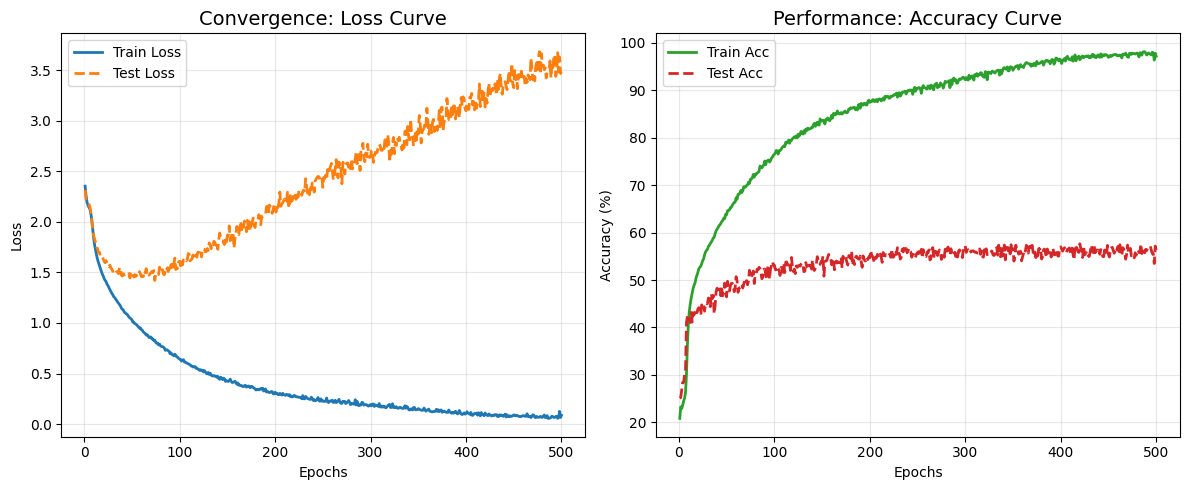


🚀 最终评估结果报表
最终测试准确率: 56.33%
最终测试 F1 值 (Macro): 0.5748


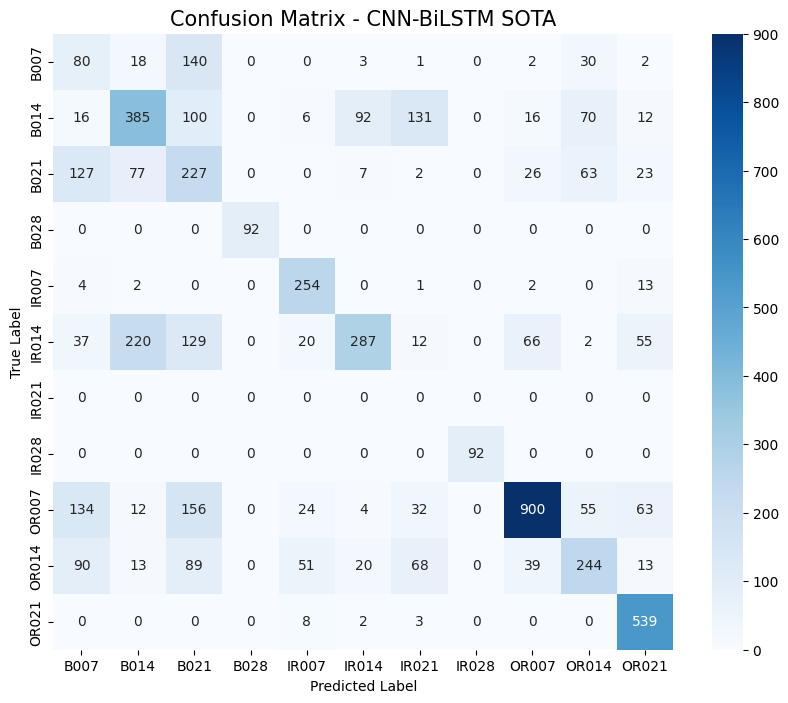


详细分类报告:
              precision    recall  f1-score   support

        B007       0.16      0.29      0.21       276
        B014       0.53      0.46      0.50       828
        B021       0.27      0.41      0.33       552
        B028       1.00      1.00      1.00        92
       IR007       0.70      0.92      0.79       276
       IR014       0.69      0.35      0.46       828
       IR021       0.00      0.00      0.00         0
       IR028       1.00      1.00      1.00        92
       OR007       0.86      0.65      0.74      1380
       OR014       0.53      0.39      0.45       627
       OR021       0.75      0.98      0.85       552

    accuracy                           0.56      5503
   macro avg       0.59      0.59      0.57      5503
weighted avg       0.64      0.56      0.58      5503



d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
if __name__ == '__main__':
    # --- 基础设置 ---
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    
    # 1. 加载数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))

    # 2. 划分数据集 (基于 ID 进行 GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    # 3. 预处理 (归一化并 Reshape 为 Conv1d 输入格式: [N, 1, 2048])
    scaler = MinMaxScaler()
    X_train_flat = X[train_idx].reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 1, 2048)
    
    X_test_flat = X[test_idx].reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 1, 2048)

    print(f"划分完成 -> 训练集: {len(X_train_flat)}, 测试集: {len(X_test_flat)}")

    # 转换为 Tensor (纯振动信号)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y[test_idx], dtype=torch.long)

    # 4. DataLoader
    batch_size = 128
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

    # 5. 初始化强化版模型
    model = ResNet_BiLSTM(num_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.00001)
    criterion = nn.CrossEntropyLoss()

    # 准备记录训练过程的容器
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # 6. 训练循环
    num_epochs = 500
    print(f"开始训练 CNN-BiLSTM SOTA 模型 (设备: {device})...")
    
    for epoch in range(num_epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- 验证阶段 ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = 100. * test_correct / test_total
        epoch_test_f1 = f1_score(all_labels, all_preds, average='macro')

        # 记录到 history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}% | F1: {epoch_test_f1:.4f}")

    # -----------------------------------------------------------
    # 7. 绘图：损失与准确率曲线 (收敛证明)
    # -----------------------------------------------------------
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    # 子图 1: Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='#ff7f0e', linestyle='--', lw=2)
    plt.title('Convergence: Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图 2: Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='#d62728', linestyle='--', lw=2)
    plt.title('Performance: Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # 8. 最终评估与混淆矩阵 (严谨性证明)
    # -----------------------------------------------------------
    print("\n" + "="*30)
    print("🚀 最终评估结果报表")
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"最终测试准确率: {epoch_test_acc:.2f}%")
    print(f"最终测试 F1 值 (Macro): {final_f1:.4f}")
    
    # 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_strs, yticklabels=label_strs)
    plt.title('Confusion Matrix - CNN-BiLSTM SOTA', fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\n详细分类报告:")
    print(classification_report(all_labels, all_preds, target_names=label_strs))

# 二、消融实验进行中
（一）CNN-LSTM

In [5]:
import torch
import torch.nn as nn

class CNN_LSTM_M1(nn.Module):
    def __init__(self, num_classes):
        super(CNN_LSTM_M1, self).__init__()
        # 1. 特征提取阶段 (保持不变，确保消融变量单一)
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=8, padding=28),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 2. 序列建模：单向 LSTM (消融点：去掉双向建模)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, 
                            num_layers=2, bidirectional=False, # 改为 False
                            batch_first=True, dropout=0.3)
        
        # 3. 分类器
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), # 维度改为 128
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x) 
        x = x.transpose(1, 2)         
        x, _ = self.lstm(x)
        x = x[:, -1, :]               # 提取最后一个时间步
        return self.classifier(x)

正在加载数据...
(27583, 2048) (27583,) (27583,)
['B007' 'B014' 'B021' 'B028' 'IR007' 'IR014' 'IR021' 'IR028' 'OR007'
 'OR014' 'OR021']
划分完成 -> 训练集: 22080, 测试集: 5503
开始训练 CNN-BiLSTM SOTA 模型 (设备: cuda)...
Epoch [01/500] Train Loss: 2.3147 | Train Acc: 17.42% | Test Loss: 2.2993 | Test Acc: 25.08% | F1: 0.0401
Epoch [02/500] Train Loss: 2.1970 | Train Acc: 22.76% | Test Loss: 2.2418 | Test Acc: 26.75% | F1: 0.0903
Epoch [03/500] Train Loss: 2.1480 | Train Acc: 23.28% | Test Loss: 2.2168 | Test Acc: 26.73% | F1: 0.0871
Epoch [04/500] Train Loss: 2.1148 | Train Acc: 23.47% | Test Loss: 2.1831 | Test Acc: 28.37% | F1: 0.2049
Epoch [05/500] Train Loss: 2.0841 | Train Acc: 24.61% | Test Loss: 2.1478 | Test Acc: 28.40% | F1: 0.2072
Epoch [06/500] Train Loss: 2.0504 | Train Acc: 25.62% | Test Loss: 2.0807 | Test Acc: 32.82% | F1: 0.3030
Epoch [07/500] Train Loss: 2.0034 | Train Acc: 26.86% | Test Loss: 2.0245 | Test Acc: 32.75% | F1: 0.3014
Epoch [08/500] Train Loss: 1.9700 | Train Acc: 27.82% | Test 

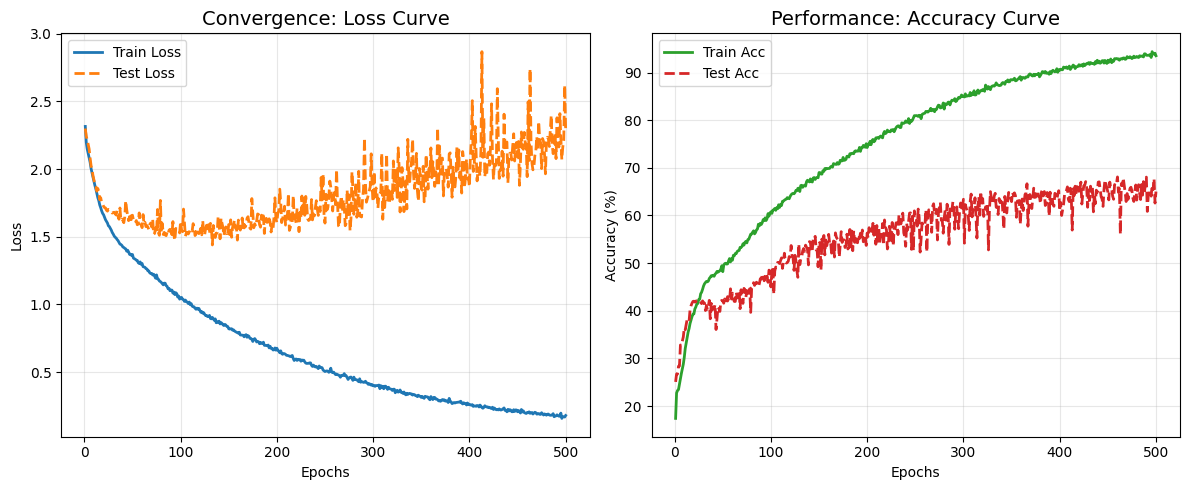


🚀 最终评估结果报表
最终测试准确率: 65.02%
最终测试 F1 值 (Macro): 0.6220


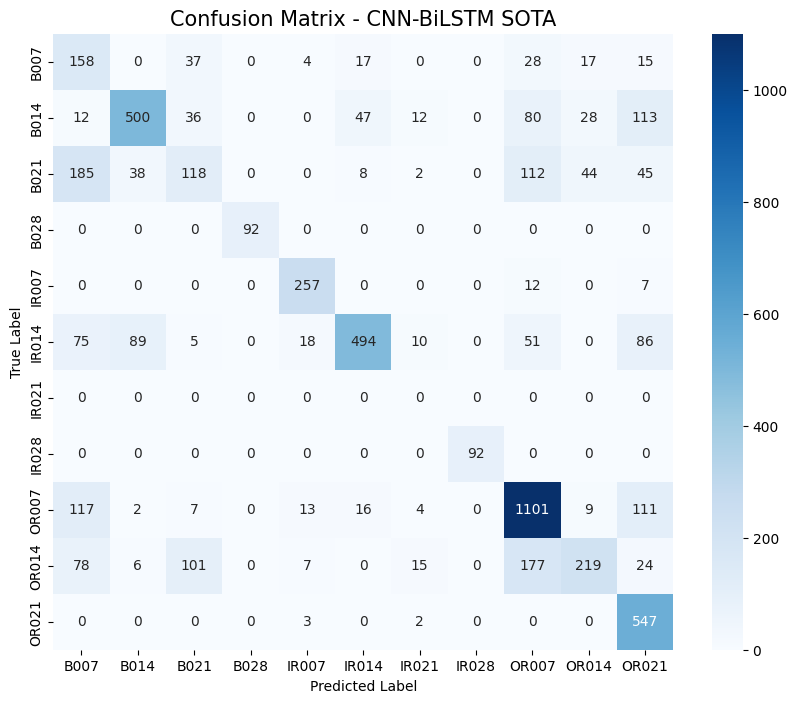


详细分类报告:
              precision    recall  f1-score   support

        B007       0.25      0.57      0.35       276
        B014       0.79      0.60      0.68       828
        B021       0.39      0.21      0.28       552
        B028       1.00      1.00      1.00        92
       IR007       0.85      0.93      0.89       276
       IR014       0.85      0.60      0.70       828
       IR021       0.00      0.00      0.00         0
       IR028       1.00      1.00      1.00        92
       OR007       0.71      0.80      0.75      1380
       OR014       0.69      0.35      0.46       627
       OR021       0.58      0.99      0.73       552

    accuracy                           0.65      5503
   macro avg       0.65      0.64      0.62      5503
weighted avg       0.69      0.65      0.65      5503



d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda\envs\pikaqiu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
if __name__ == '__main__':
    # --- 基础设置 ---
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    
    # 1. 加载数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))

    # 2. 划分数据集 (基于 ID 进行 GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    # 3. 预处理 (归一化并 Reshape 为 Conv1d 输入格式: [N, 1, 2048])
    scaler = MinMaxScaler()
    X_train_flat = X[train_idx].reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 1, 2048)
    
    X_test_flat = X[test_idx].reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 1, 2048)

    print(f"划分完成 -> 训练集: {len(X_train_flat)}, 测试集: {len(X_test_flat)}")

    # 转换为 Tensor (纯振动信号)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y[test_idx], dtype=torch.long)

    # 4. DataLoader
    batch_size = 128
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

    # 5. 初始化强化版模型
    model = CNN_LSTM_M1(num_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.00005)
    criterion = nn.CrossEntropyLoss()

    # 准备记录训练过程的容器
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # 6. 训练循环
    num_epochs = 500
    print(f"开始训练 CNN-BiLSTM SOTA 模型 (设备: {device})...")
    
    for epoch in range(num_epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- 验证阶段 ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = 100. * test_correct / test_total
        epoch_test_f1 = f1_score(all_labels, all_preds, average='macro')

        # 记录到 history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}% | F1: {epoch_test_f1:.4f}")

    # -----------------------------------------------------------
    # 7. 绘图：损失与准确率曲线 (收敛证明)
    # -----------------------------------------------------------
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    # 子图 1: Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='#ff7f0e', linestyle='--', lw=2)
    plt.title('Convergence: Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图 2: Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='#d62728', linestyle='--', lw=2)
    plt.title('Performance: Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # 8. 最终评估与混淆矩阵 (严谨性证明)
    # -----------------------------------------------------------
    print("\n" + "="*30)
    print("🚀 最终评估结果报表")
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"最终测试准确率: {epoch_test_acc:.2f}%")
    print(f"最终测试 F1 值 (Macro): {final_f1:.4f}")
    
    # 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_strs, yticklabels=label_strs)
    plt.title('Confusion Matrix - CNN-BiLSTM SOTA', fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\n详细分类报告:")
    print(classification_report(all_labels, all_preds, target_names=label_strs))

## （二） M2
在基础模型上融入物理特征进行手动拼贴 送入分类器

In [ ]:
import torch
import torch.nn as nn

class CNN_LSTM_Static_Hybrid_M2(nn.Module):
    def __init__(self, num_classes, manual_feature_dim):
        super(CNN_LSTM_Static_Hybrid_M2, self).__init__()
        
        # 1. 深度特征流 (与 M1 完全一致)
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=8, padding=28),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, 
                            num_layers=2, bidirectional=False, 
                            batch_first=True, dropout=0.3)
        
        # 2. 分类器：输入维度 = 深度特征(128) + 手动特征维度
        # 消融点：直接拼接 (torch.cat)，不进行线性映射，不加门控
        combined_dim = 128 + manual_feature_dim
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_raw, x_manual):
        # 处理深度信号
        x = self.feature_extractor(x_raw) 
        x = x.transpose(1, 2)         
        x, _ = self.lstm(x)
        deep_features = x[:, -1, :] # 提取最后一个时间步的深度特征 (128维)
        
        # 核心消融操作：直接拼接手动特征
        # deep_features: [batch, 128], x_manual: [batch, 40]
        fused_features = torch.cat((deep_features, x_manual), dim=1)
        
        return self.classifier(fused_features)

In [ ]:
if __name__ == '__main__':
    # --- 基础设置 ---
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("正在加载数据...")
    data_path = r'E:\故障诊断2\实验整理\dataset\processed\npz\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.npz'
    # 1. 加载数据
    X, y, label_strs, label_ids, ids = use.load_npz_dataset(data_path)
    n_classes = len(np.unique(y))

    # 2. 划分数据集 (基于 ID 进行 GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=ids))

    # 3. 预处理 (归一化并 Reshape 为 Conv1d 输入格式: [N, 1, 2048])
    scaler = MinMaxScaler()
    X_train_flat = X[train_idx].reshape(-1, 2048)
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 1, 2048)
    
    X_test_flat = X[test_idx].reshape(-1, 2048)
    X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 1, 2048)

    print(f"划分完成 -> 训练集: {len(X_train_flat)}, 测试集: {len(X_test_flat)}")

    # 转换为 Tensor (纯振动信号)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y[test_idx], dtype=torch.long)
    
    #新增手动特征===：
    # 加载手动提取的特征
    feature_csv_path = r"E:\故障诊断2\实验整理\dataset\processed\csv\cond_sampling_rates_12_sampling_positions_DE-BA-FE_loads_0-1-2-3_win2048_step1024.csv"
    feature_df = pd.read_csv(feature_csv_path)
    print('手动特征数据维度:',feature_df.shape)

    feature_cols = [col for col in feature_df.columns if col not in ['label', 'sorce']]
    X_manual_np = feature_df[feature_cols].values # (N, 40)
    print(f"手动特征维度: {X_manual_np.shape}")

    # --- 将手动特征按 ID 划分 ---
    X_manual_train_raw = X_manual_np[train_idx]
    X_manual_test_raw = X_manual_np[test_idx]

    # --- 归一化手动特征 (防泄露：只在训练集上 fit) ---
    # 注意：这里也需要对人工特征进行归一化，以匹配深度特征的数值尺度。
    # 推荐使用 StandardScaler 或 MinMaxScaler
    manual_scaler = StandardScaler() 

    # 1. 在训练集上 fit 并 transform
    X_manual_train_scaled = manual_scaler.fit_transform(X_manual_train_raw)

    # 2. 在测试集上仅 transform 
    X_manual_test_scaled = manual_scaler.transform(X_manual_test_raw)

    # --- 转换为 Tensor ---
    # 振动信号 Tensor 保持不变 (X_train, y_train, X_test, y_test)

    # 新增手动特征 Tensor
    X_manual_train = torch.tensor(X_manual_train_scaled, dtype=torch.float32)
    X_manual_test = torch.tensor(X_manual_test_scaled, dtype=torch.float32)
        
    manual_feature_dim = X_manual_train.shape[1] 

    # 4. DataLoader (注意这里需要三元组: 信号, 手动特征, 标签)
    batch_size = 128
    train_dataset = TensorDataset(X_train_t, X_manual_train, y_train_t)
    test_dataset = TensorDataset(X_test_t, X_manual_test, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 5. 初始化 M2 模型
    model = CNN_LSTM_Static_Hybrid_M2(num_classes=n_classes, manual_feature_dim=manual_feature_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.00005)
    criterion = nn.CrossEntropyLoss()

    # 准备记录训练过程的容器
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    # 6. 训练循环
    num_epochs = 500
    print(f"开始训练M2: Static Hybrid 消融实验 (设备: {device})...")
    
    for epoch in range(num_epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100. * train_correct / train_total

        # --- 验证阶段 ---
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = 100. * test_correct / test_total
        epoch_test_f1 = f1_score(all_labels, all_preds, average='macro')

        # 记录到 history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}% | F1: {epoch_test_f1:.4f}")

    # -----------------------------------------------------------
    # 7. 绘图：损失与准确率曲线 (收敛证明)
    # -----------------------------------------------------------
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    # 子图 1: Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='#ff7f0e', linestyle='--', lw=2)
    plt.title('Convergence: Loss Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 子图 2: Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    plt.plot(epochs_range, history['test_acc'], label='Test Acc', color='#d62728', linestyle='--', lw=2)
    plt.title('Performance: Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # 8. 最终评估与混淆矩阵 (严谨性证明)
    # -----------------------------------------------------------
    print("\n" + "="*30)
    print("🚀 最终评估结果报表")
    final_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"最终测试准确率: {epoch_test_acc:.2f}%")
    print(f"最终测试 F1 值 (Macro): {final_f1:.4f}")
    
    # 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_strs, yticklabels=label_strs)
    plt.title('Confusion Matrix - CNN-BiLSTM SOTA', fontsize=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\n详细分类报告:")
    print(classification_report(all_labels, all_preds, target_names=label_strs))

In [8]:
import torch

def count_parameters(model):
    """统计模型的总参数量和可训练参数量"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # 转换为百万 (M) 为单位
    return total_params / 1e6, trainable_params / 1e6

def model_complexity_report(models_dict, input_size=(1, 1, 2048)):
    """
    输出对比报告
    models_dict: {'模型名称': 模型实例}
    """
    print(f"{'Model Name':<20} | {'Total Params (M)':<20} | {'Model Size (MB)':<15}")
    print("-" * 60)
    
    for name, model in models_dict.items():
        total, trainable = count_parameters(model)
        
        # 计算模型内存占用 (假设是 float32, 每个参数 4 bytes)
        param_size = 0
        for param in model.parameters():
            param_size += param.nelement() * param.element_size()
        buffer_size = 0
        for buffer in model.buffers():
            buffer_size += buffer.nelement() * buffer.element_size()
            
        size_all_mb = (param_size + buffer_size) / 1024**2
        
        print(f"{name:<20} | {total:<20.4f} | {size_all_mb:<15.2f}")

# 使用示例
if __name__ == '__main__':
    # 假设你的类别数是 10
    n_classes = 10 
    
    # 实例化所有模型
    models = {
        "WDCNN": WDCNN(num_classes=n_classes),
        "CNN-BiLSTM": CNN_BiLSTM_SOTA(num_classes=n_classes),
        "ResNet-BiLSTM": ResNet_BiLSTM(num_classes=n_classes),
        "CNN_LSTM_M1":CNN_LSTM_M1(num_classes=n_classes)
        # "Your_Model": YourFusionModel(...) # 别忘了把你的模型也放进去对比！
    }
    
    print("模型复杂度对比报告")
    model_complexity_report(models)

模型复杂度对比报告
Model Name           | Total Params (M)     | Model Size (MB)
------------------------------------------------------------
WDCNN                | 0.0604               | 0.23           
CNN-BiLSTM           | 0.6201               | 2.37           
ResNet-BiLSTM        | 0.8961               | 3.43           
CNN_LSTM_M1          | 0.2494               | 0.95           
